# 01. Исследовательский анализ данных

Цель ноутбука — проверить качество ежемесячных снимков клиентов Santander, описать демографию и текущие продуктовые портфели, а затем исследовать **новые покупки**. Целевая переменная определяется только как переход продукта из `0` в месяце $t$ в `1` в соседнем месяце $t+1$.

Полный CSV занимает около 2.29 ГБ, поэтому он сканируется по частям. В выборку стабильно попадают одни и те же клиенты во всех месяцах — это сохраняет их временную историю. По умолчанию используется 0.5% клиентов; долю можно изменить переменной окружения `EDA_SAMPLE_FRACTION`. Все случайные состояния зафиксированы значением 42.

In [1]:
from pathlib import Path
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
    else:
        raise RuntimeError("Запустите ноутбук из корня проекта или каталога notebooks")

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from bank_recommender.constants import (
    DATE_COLUMN,
    ID_COLUMN,
    PRODUCT_COLUMNS,
    PRODUCT_DESCRIPTIONS_RU,
)
from bank_recommender.data import build_temporal_pairs, read_sampled_snapshots

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

raw_data_path = Path(os.getenv("DATA_PATH", "train_ver2.csv")).expanduser()
DATA_PATH = raw_data_path if raw_data_path.is_absolute() else PROJECT_ROOT / raw_data_path
EDA_SAMPLE_FRACTION = float(os.getenv("EDA_SAMPLE_FRACTION", "0.005"))
if not 0 < EDA_SAMPLE_FRACTION <= 1:
    raise ValueError("EDA_SAMPLE_FRACTION должна находиться в интервале (0, 1]")
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Датасет не найден: {DATA_PATH}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Данные: {DATA_PATH}")
print(f"Доля стабильной выборки клиентов: {EDA_SAMPLE_FRACTION:.3%}; seed={SEED}")

Корень проекта: .
Данные: train_ver2.csv
Доля стабильной выборки клиентов: 0.500%; seed=42


## 1. Полный набор данных и стратегия чтения

В полном `train_ver2.csv` фактически **13 647 309 строк данных и 48 колонок** (без строки заголовка). Первые 24 колонки описывают дату и профиль клиента, следующие 24 — наличие банковских продуктов. Число строк проверено подсчётом строк файла, а число колонок ниже дополнительно сверяется по заголовку без загрузки всего CSV в память.

Простая случайная выборка строк разрушила бы пары месяцев одного клиента. `read_sampled_snapshots` читает CSV чанками и использует детерминированный хеш `ncodpers`, поэтому выбранный клиент сохраняется во всех доступных месяцах.

In [2]:
FULL_DATA_ROWS = 13_647_309
FULL_DATA_COLUMNS = 48
header = pd.read_csv(DATA_PATH, nrows=0)
if len(header.columns) != FULL_DATA_COLUMNS:
    raise ValueError(
        f"Ожидалось {FULL_DATA_COLUMNS} колонок, найдено {len(header.columns)}"
    )

full_dataset_facts = pd.DataFrame(
    {
        "значение": [
            FULL_DATA_ROWS,
            len(header.columns),
            len(PRODUCT_COLUMNS),
            DATA_PATH.stat().st_size / 1024**3,
        ]
    },
    index=["строк данных", "колонок", "продуктовых колонок", "размер, GiB"],
)
display(full_dataset_facts)

,значение
строк данных,"13,647,309.0000"
колонок,48.0000
продуктовых колонок,24.0000
"размер, GiB",2.1353


## 2. Стабильная выборка снимков

Загрузчик нормализует пробелы и типы, преобразует дату, приводит продуктовые индикаторы к `0/1`, сортирует снимки по клиенту и дате и оставляет последнюю запись для дубликата `(ncodpers, fecha_dato)`. Все следующие расчёты используют один объект `snapshots`, повторного сканирования CSV нет.

In [3]:
snapshots = read_sampled_snapshots(
    DATA_PATH,
    sample_fraction=EDA_SAMPLE_FRACTION,
    random_seed=SEED,
)

sample_overview = pd.DataFrame(
    {
        "значение": [
            snapshots.shape[0],
            snapshots.shape[1],
            snapshots[ID_COLUMN].nunique(),
            snapshots[DATE_COLUMN].nunique(),
            snapshots[DATE_COLUMN].min().date(),
            snapshots[DATE_COLUMN].max().date(),
        ]
    },
    index=[
        "строк выборки",
        "колонок выборки",
        "уникальных клиентов",
        "месячных срезов",
        "минимальная дата",
        "максимальная дата",
    ],
)
display(sample_overview)
display(snapshots.head(3))

,значение
строк выборки,68912
колонок выборки,45
уникальных клиентов,4834
месячных срезов,17
минимальная дата,2015-01-28
максимальная дата,2016-05-28


,ncodpers,fecha_dato,age,ind_nuevo,antiguedad,indrel,tipodom,ind_actividad_cliente,renta,ind_empleado,pais_residencia,sexo,indrel_1mes,tiprel_1mes,indresi,indext,canal_entrada,indfall,cod_prov,nomprov,segmento,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,ind_deme_fin_ult1,ind_dela_fin_ult1,ind_ecue_fin_ult1,ind_fond_fin_ult1,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,15945,2015-07-28,48.0000,0.0000,246.0000,1.0000,1.0000,0.0000,NaN,N,ES,H,1,I,S,N,KAT,N,28.0,MADRID,02 - PARTICULARES,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,15945,2015-08-28,49.0000,0.0000,247.0000,1.0000,1.0000,0.0000,NaN,N,ES,H,1,I,S,N,KAT,N,28.0,MADRID,02 - PARTICULARES,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,15945,2015-09-28,49.0000,0.0000,248.0000,1.0000,1.0000,0.0000,NaN,N,ES,H,1,I,S,N,KAT,N,28.0,MADRID,02 - PARTICULARES,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Качество данных: дубликаты и пропуски

Дубликаты ниже проверяются после штатной нормализации: ожидается ноль повторов ключа клиент–месяц. Пропуски в профиле сохраняются и будут обрабатываться внутри ML-pipeline. Пропуски продуктовых индикаторов трактуются загрузчиком как отсутствие продукта (`0`); это решение необходимо явно учитывать при интерпретации редких ранних записей.

In [4]:
duplicate_rows = int(snapshots.duplicated().sum())
duplicate_customer_months = int(
    snapshots.duplicated([ID_COLUMN, DATE_COLUMN]).sum()
)
quality_checks = pd.Series(
    {
        "полных дубликатов после нормализации": duplicate_rows,
        "дубликатов клиент-месяц после нормализации": duplicate_customer_months,
        "строк с пропуском идентификатора": int(snapshots[ID_COLUMN].isna().sum()),
        "строк с пропуском даты": int(snapshots[DATE_COLUMN].isna().sum()),
    },
    name="количество",
)
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": snapshots.isna().sum(),
            "missing_pct": snapshots.isna().mean().mul(100),
        }
    )
    .sort_values(["missing_pct", "missing_count"], ascending=False)
)

display(quality_checks.to_frame())
display(missing_summary.head(15))

,количество
полных дубликатов после нормализации,0
дубликатов клиент-месяц после нормализации,0
строк с пропуском идентификатора,0
строк с пропуском даты,0


,missing_count,missing_pct
renta,14401,20.8977
segmento,950,1.3786
canal_entrada,945,1.3713
indrel_1mes,787,1.1420
tiprel_1mes,787,1.1420
cod_prov,497,0.7212
nomprov,497,0.7212
age,163,0.2365
ind_nuevo,163,0.2365
antiguedad,163,0.2365


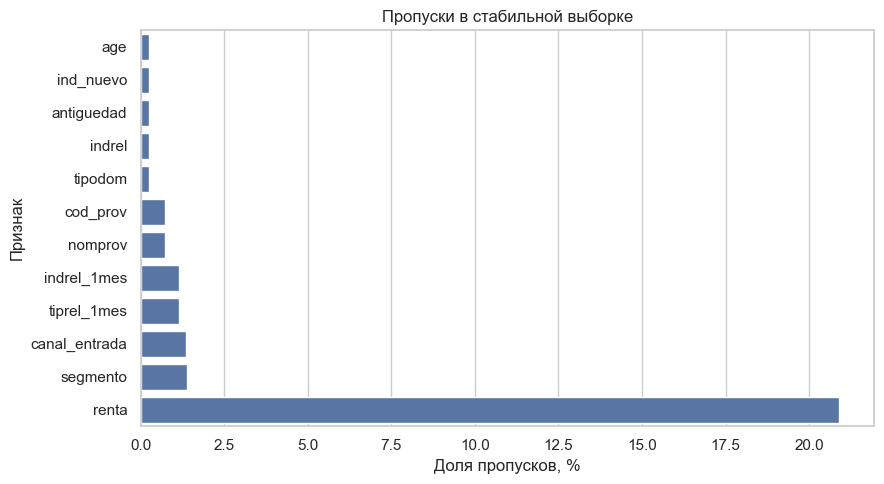

In [5]:
missing_plot = (
    missing_summary.head(12)
    .sort_values("missing_pct")
    .reset_index(names="column")
)
plt.figure(figsize=(9, 5))
sns.barplot(data=missing_plot, x="missing_pct", y="column", color="#4C72B0")
plt.title("Пропуски в стабильной выборке")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## 4. Демографический профиль

Возраст и доход анализируются только после числового приведения. Для категориальных полей выводятся несколько наиболее частых значений, чтобы не создавать таблицы на сотни категорий. Экстремальные и отсутствующие значения нельзя заполнять по всему датасету до временного split: медианы и словари категорий должны обучаться только на train.

In [6]:
numeric_profile = snapshots[["age", "antiguedad", "renta"]].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T
category_rows = []
for column in ["sexo", "segmento", "ind_actividad_cliente", "pais_residencia"]:
    shares = snapshots[column].astype("string").fillna("<NA>").value_counts(
        normalize=True
    ).head(5)
    category_rows.extend(
        {"признак": column, "значение": value, "доля": share}
        for value, share in shares.items()
    )

display(numeric_profile)
display(pd.DataFrame(category_rows))

,count,mean,std,min,1%,25%,50%,75%,99%,max
age,"68,749.0000",40.2655,17.2545,2.0000,20.0000,24.0000,39.0000,50.0000,89.0000,105.0000
antiguedad,"68,749.0000",78.8353,66.1093,0.0000,0.0000,23.0000,50.0000,134.0000,231.0000,256.0000
renta,"54,511.0000","137,205.4688","252,732.4688","8,034.1499","25,955.1602","68,859.3906","101,492.8516","155,212.6562","570,075.3125","9,833,873.0000"


,признак,значение,доля
0,sexo,V,0.5406
1,sexo,H,0.4570
2,sexo,<NA>,0.0024
3,segmento,02 - PARTICULARES,0.5812
4,segmento,03 - UNIVERSITARIO,0.3626
5,segmento,01 - TOP,0.0424
6,segmento,<NA>,0.0138
7,ind_actividad_cliente,0.0,0.5366
8,ind_actividad_cliente,1.0,0.4610
9,ind_actividad_cliente,<NA>,0.0024


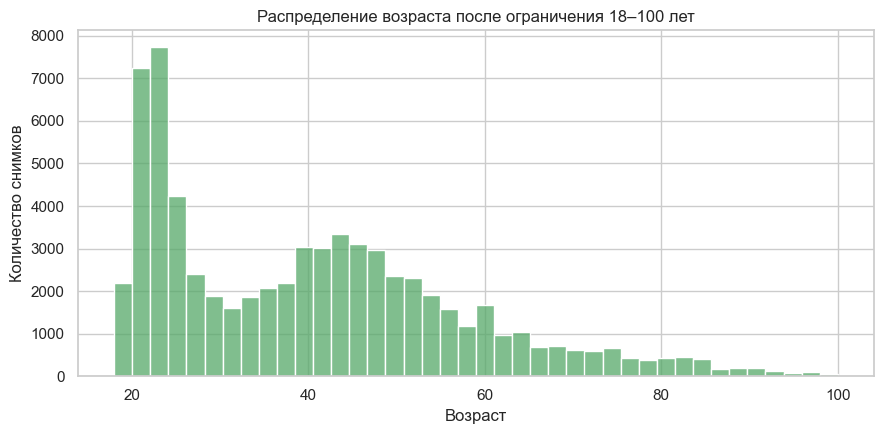

In [7]:
valid_age = pd.to_numeric(snapshots["age"], errors="coerce")
valid_age = valid_age[valid_age.between(18, 100)]
plt.figure(figsize=(9, 4.5))
sns.histplot(valid_age, bins=40, color="#55A868")
plt.title("Распределение возраста после ограничения 18–100 лет")
plt.xlabel("Возраст")
plt.ylabel("Количество снимков")
plt.tight_layout()
plt.show()

## 5. Текущий продуктовый портфель

Индикаторы в снимке отвечают на вопрос «какие продукты уже есть у клиента», но это ещё не target. Их частоты важны как baseline и как признаки текущего портфеля. Сильная концентрация владений вокруг нескольких массовых продуктов означает, что обычная accuracy будет почти полностью определяться отрицательным классом.

In [8]:
current_product_table = pd.DataFrame(
    {
        "product": PRODUCT_COLUMNS,
        "description": [PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
        "owners_in_sample": [int(snapshots[p].sum()) for p in PRODUCT_COLUMNS],
        "snapshot_prevalence": [float(snapshots[p].mean()) for p in PRODUCT_COLUMNS],
    }
).sort_values("snapshot_prevalence", ascending=False, ignore_index=True)
display(current_product_table.head(12))

,product,description,owners_in_sample,snapshot_prevalence
0,ind_cco_fin_ult1,Текущий счёт,44565,0.6467
1,ind_ctop_fin_ult1,Особый счёт,9340,0.1355
2,ind_recibo_ult1,Счёт прямого дебета,9149,0.1328
3,ind_cno_fin_ult1,Зарплатный проект,5814,0.0844
4,ind_ecue_fin_ult1,Цифровой счёт,5611,0.0814
5,ind_nom_pens_ult1,Пенсионные обязательства,4219,0.0612
6,ind_nomina_ult1,Зарплатный счёт,3855,0.0559
7,ind_reca_fin_ult1,Налоговый счёт,3546,0.0515
8,ind_dela_fin_ult1,Долгосрочный депозит,3251,0.0472
9,ind_tjcr_fin_ult1,Кредитная карта,3008,0.0436


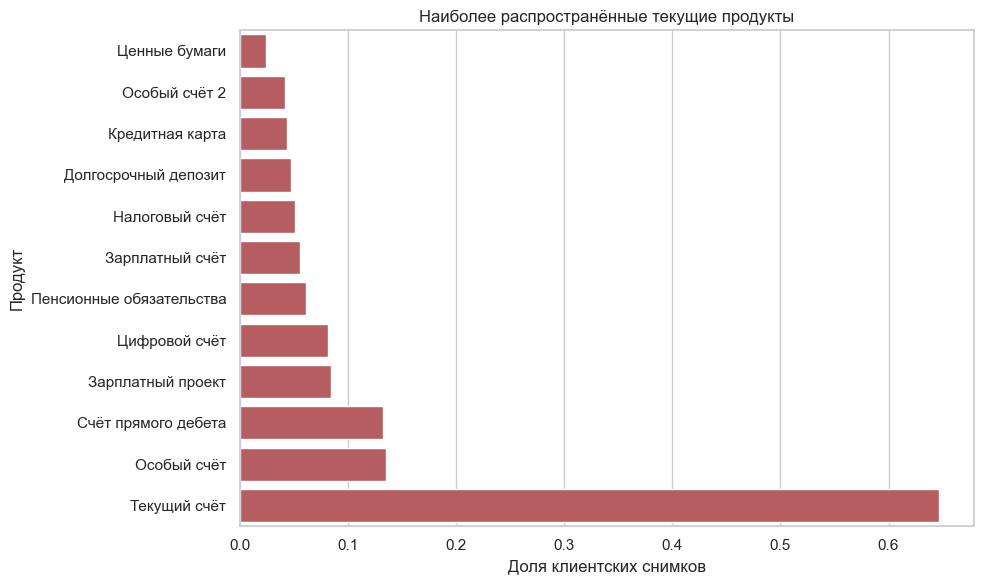

In [9]:
product_plot = current_product_table.head(12).sort_values("snapshot_prevalence")
plt.figure(figsize=(10, 6))
sns.barplot(
    data=product_plot,
    x="snapshot_prevalence",
    y="description",
    color="#C44E52",
)
plt.title("Наиболее распространённые текущие продукты")
plt.xlabel("Доля клиентских снимков")
plt.ylabel("Продукт")
plt.tight_layout()
plt.show()

## 6. Новые покупки: переходы 0→1

`build_temporal_pairs` соединяет клиента только с **соседним календарным месяцем**. Для каждой продуктовой колонки вычисляется $y=\max(x_{t+1}-x_t, 0)$. Снятие продукта (`1→0`) не является покупкой, а разрыв в несколько месяцев не создаёт пару. Признаки остаются в месяце $t$, поэтому будущая информация не попадает в модель.

In [10]:
pairs = build_temporal_pairs(snapshots)
additions_per_pair = pairs.targets[PRODUCT_COLUMNS].sum(axis=1)
target_month = (pairs.periods + 1).astype(str)

pair_summary = pd.Series(
    {
        "соседних пар клиент-месяц": len(pairs.features),
        "всего событий 0→1": int(additions_per_pair.sum()),
        "доля пар хотя бы с одной покупкой": float((additions_per_pair > 0).mean()),
        "среднее число покупок на пару": float(additions_per_pair.mean()),
        "максимум покупок в одной паре": int(additions_per_pair.max()),
    },
    name="значение",
)
addition_table = pd.DataFrame(
    {
        "product": PRODUCT_COLUMNS,
        "description": [PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
        "addition_events": [int(pairs.targets[p].sum()) for p in PRODUCT_COLUMNS],
        "addition_rate": [float(pairs.targets[p].mean()) for p in PRODUCT_COLUMNS],
    }
).sort_values("addition_events", ascending=False, ignore_index=True)

display(pair_summary.to_frame())
display(addition_table.head(12))

,значение
соседних пар клиент-месяц,"64,040.0000"
всего событий 0→1,"2,872.0000"
доля пар хотя бы с одной покупкой,0.0351
среднее число покупок на пару,0.0448
максимум покупок в одной паре,4.0000


,product,description,addition_events,addition_rate
0,ind_recibo_ult1,Счёт прямого дебета,750,0.0117
1,ind_nom_pens_ult1,Пенсионные обязательства,460,0.0072
2,ind_nomina_ult1,Зарплатный счёт,410,0.0064
3,ind_tjcr_fin_ult1,Кредитная карта,348,0.0054
4,ind_cco_fin_ult1,Текущий счёт,347,0.0054
5,ind_cno_fin_ult1,Зарплатный проект,181,0.0028
6,ind_ecue_fin_ult1,Цифровой счёт,132,0.0021
7,ind_dela_fin_ult1,Долгосрочный депозит,77,0.0012
8,ind_reca_fin_ult1,Налоговый счёт,52,0.0008
9,ind_ctma_fin_ult1,Особый счёт 3,29,0.0005


,addition_events,customer_pairs,events_per_1000_pairs
target_month,,,
2015-02,188,3155,59.5880
2015-03,153,3164,48.3565
2015-04,191,3173,60.1954
2015-05,135,3176,42.5063
2015-06,219,3175,68.9764
2015-07,161,3181,50.6130
2015-08,132,4180,31.5789
2015-09,194,4245,45.7008
2015-10,185,4361,42.4215


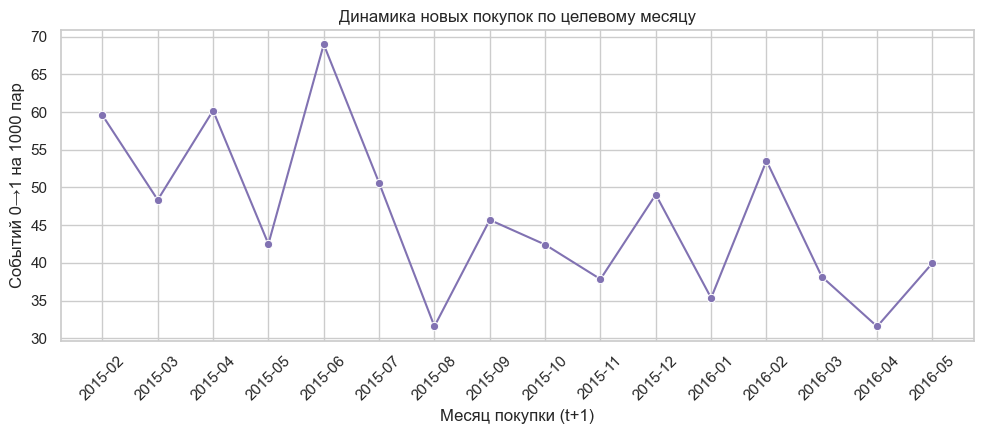

In [11]:
target_frame = pairs.targets[PRODUCT_COLUMNS].copy()
target_frame["target_month"] = target_month.to_numpy()
monthly_product_additions = target_frame.groupby("target_month")[PRODUCT_COLUMNS].sum()
monthly_pair_count = target_frame.groupby("target_month").size()
monthly_additions = pd.DataFrame(
    {
        "addition_events": monthly_product_additions.sum(axis=1),
        "customer_pairs": monthly_pair_count,
    }
)
monthly_additions["events_per_1000_pairs"] = (
    1000 * monthly_additions["addition_events"] / monthly_additions["customer_pairs"]
)
display(monthly_additions)

plt.figure(figsize=(10, 4.5))
sns.lineplot(
    data=monthly_additions.reset_index(),
    x="target_month",
    y="events_per_1000_pairs",
    marker="o",
    color="#8172B2",
)
plt.title("Динамика новых покупок по целевому месяцу")
plt.xlabel("Месяц покупки (t+1)")
plt.ylabel("Событий 0→1 на 1000 пар")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Выводы и последствия для моделирования

1. **Цель существенно разрежена.** Большинство пар клиент–месяц не содержит ни одной покупки, а редкие продукты дают крайне мало положительных примеров. Accuracy и ROC-AUC могут выглядеть высокими при бесполезном ранжировании, поэтому основная offline-метрика проекта — MAP@7, дополненная Recall@7, Precision@7, coverage и macro PR-AUC.
2. **Текущие владения и новые покупки — разные величины.** Популярность текущих счетов нельзя выдавать за частоту target. Обучение использует только переходы `0→1`; продукты, уже имеющиеся у клиента в $t$, должны маскироваться при ранжировании.
3. **Пропуски неоднородны.** Профильные поля содержат отсутствующие значения, а некоторые категории редки. Заполнение числовых признаков, кодирование категорий и обработка неизвестных значений должны находиться внутри pipeline, обученного только на train. Продуктовые пропуски загрузчик приводит к нулю как документированное допущение.
4. **Нужен временной split.** Случайное разделение строк одного клиента смешало бы прошлое и будущее. Для финальной оценки признаки апреля 2016 года используются для прогноза покупок мая; все более ранние пары образуют train.
5. **Выборка пригодна для разработки, но не заменяет полное обучение.** Детерминированный клиентский sample сохраняет траектории, однако оценки для наиболее редких продуктов имеют большую дисперсию. Финальная модель должна быть обучена CLI на большей доле или полном наборе с тем же seed и тем же временным протоколом.
6. **Прогноз после доступной истории.** Последний снимок относится к маю 2016 года, поэтому после выбора конфигурации модель можно переобучить на всех наблюдаемых соседних парах и применять к майскому портфелю для ранжирования продуктов июня.